# Lesson 6: Building makemore Part 5 — WaveNet

**Video:** [Andrej Karpathy — Building makemore Part 5: Building a WaveNet](https://www.youtube.com/watch?v=t3YJ5hKiMQ0)

---

In this lesson we take the character-level language model we've been building across lessons 2–5 and give it a **hierarchical** architecture inspired by [WaveNet (van den Oord et al., 2016)](https://arxiv.org/abs/1609.03499). Instead of squashing the entire context window into a single flat vector, we process it **bottom-up** — first learning patterns between adjacent character pairs, then combining those into longer-range patterns, and so on.

### Roadmap

| Section                         | What we do                                                                                        |
| ------------------------------- | ------------------------------------------------------------------------------------------------- |
| **0. Setup**                    | Imports, dataset, vocabulary                                                                      |
| **1. Repackaging into Modules** | Wrap our raw tensor math from lesson 4 into composable layer classes                              |
| **2. Flat MLP Baseline**        | Establish a baseline with the flat architecture at `block_size=8`                                 |
| **3. Motivating the Hierarchy** | _Why_ we need a hierarchical approach — the problem, the WaveNet insight, and 3D matmul mechanics |
| **4. FlattenConsecutive**       | Build the layer that merges consecutive timesteps                                                 |
| **5. Building the WaveNet**     | Incrementally discover and fix issues (the heart of the notebook)                                 |
| **6. Training Diagnostics**     | Verify healthy activations and gradients                                                          |
| **7. Sampling**                 | Generate names from both models                                                                   |
| **8. Deeper Understanding**     | What each level learns, connection to the original paper                                          |
| **9. Summary**                  | Progression table, connection to transformers, looking ahead                                      |

### Cross-references

- **Lesson 2–3:** Where we first built the character-level MLP and embedding lookup
- **Lesson 4 (Part 1):** Kaiming initialization, BatchNorm, why output scaling matters
- **Lesson 4 (Part 2):** Training diagnostics — activation/gradient distributions, update-to-data ratios
- **Lesson 5:** Manual backprop through the network ("becoming a backprop ninja")


In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import random

%matplotlib inline

DATASET_PATH = '../names.txt'
SPECIAL_TOKEN = '.'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [2]:
# Load dataset and build character vocabulary
with open(DATASET_PATH, 'r') as f:
    words = [row.strip() for row in f.readlines()]
print(f'{len(words)} names loaded')

all_characters = [SPECIAL_TOKEN] + sorted(list(set(''.join(words))))
stoi = {s: i for i, s in enumerate(all_characters)}
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(f'Vocabulary size: {vocab_size} characters')
print(f'Characters: {" ".join(all_characters)}')

32033 names loaded
Vocabulary size: 27 characters
Characters: . a b c d e f g h i j k l m n o p q r s t u v w x y z


In [3]:
# Build dataset with block_size=8 (up from 3 in previous lessons)
block_size = 8

def build_dataset(words, block_size=8):
    """
    Convert a list of words into (X, Y) tensors for training.

    X shape: (N, block_size) — each row is a context window of character indices
    Y shape: (N,) — each element is the target character index
    """
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + SPECIAL_TOKEN:
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

# Train/val/test split (80/10/10) — split at word level, not example level
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1], block_size=block_size)
Xdev, Ydev = build_dataset(words[n1:n2], block_size=block_size)
Xte, Yte = build_dataset(words[n2:], block_size=block_size)

Xtr, Ytr = Xtr.to(device), Ytr.to(device)
Xdev, Ydev = Xdev.to(device), Ydev.to(device)
Xte, Yte = Xte.to(device), Yte.to(device)

print(f'Training:   {Xtr.shape[0]:>7,} examples from {n1:,} names')
print(f'Validation: {Xdev.shape[0]:>7,} examples from {n2-n1:,} names')
print(f'Test:       {Xte.shape[0]:>7,} examples from {len(words)-n2:,} names')

Training:   182,625 examples from 25,626 names
Validation:  22,655 examples from 3,203 names
Test:        22,866 examples from 3,204 names


In [4]:
# Visualize a few expanded context examples
print('Example context windows (block_size=8):\n')
for i in range(5):
    context_chars = [itos[ix.item()] for ix in Xtr[i]]
    target_char = itos[Ytr[i].item()]
    print(f'  {"".join(context_chars)} --> {target_char}')

Example context windows (block_size=8):

  ........ --> y
  .......y --> u
  ......yu --> h
  .....yuh --> e
  ....yuhe --> n


---

## Section 1: Repackaging into Modules

In lesson 4 we built our neural network using raw tensor math — manually creating weight matrices, doing `x @ W + b`, applying tanh, etc. This works, but as the network grows it becomes unwieldy. We want **composable layer objects** — each layer knows how to do its forward pass, what parameters it owns, and stores its output for diagnostics.

This is exactly the design pattern PyTorch uses with `torch.nn.Module`. We're building a simplified version here to understand what's happening under the hood.


In [5]:
# --- Layer classes carried forward from Lesson 4 ---
# These are the ORIGINAL versions — we'll discover issues and fix them incrementally later.

class Linear:
    """A fully connected layer: y = x @ W + b, with Kaiming He initialization."""

    def __init__(self, fan_in, fan_out, bias=True):
        self.weights = torch.randn((fan_in, fan_out), device=device) / fan_in**0.5
        self.bias = torch.zeros(fan_out, device=device) if bias else None

    def __call__(self, x):
        self.out = x @ self.weights
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weights, self.bias] if self.bias is not None else [self.weights]

    def __repr__(self):
        return f'Linear({self.weights.shape[0]}, {self.weights.shape[1]})'


class BatchNorm1d:
    """Batch normalization: normalizes pre-activations to zero mean / unit variance,
    then applies a learnable scale (gamma) and shift (beta).

    NOTE: This is the Lesson 4 version — it only handles 2D inputs (B, C).
    We'll discover a bug when we feed it 3D inputs later.
    """

    def __init__(self, num_features, momentum=0.001, eps=1e-5):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # learnable scale and shift
        self.gamma = torch.ones(num_features, device=device)
        self.beta = torch.zeros(num_features, device=device)

        # running stats for inference
        self.running_mean = torch.zeros(num_features, device=device)
        self.running_var = torch.ones(num_features, device=device)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

    def __repr__(self):
        return f'BatchNorm1d({self.gamma.shape[0]})'


class Tanh:
    """Tanh activation function, stores output for diagnostic access."""

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

    def __repr__(self):
        return 'Tanh()'

### New classes: `Embedding` and `FlattenConsecutive`

In lesson 4 the embedding lookup `C[x]` lived outside the layer abstraction. Now we wrap it into an `Embedding` class so it can participate in the same `for layer in layers` forward pass.

We also define a placeholder `FlattenConsecutive` — we'll build its real logic in Section 4, but we need a simple "flatten everything" version for the baseline.


In [6]:
class Embedding:
    """Wraps an embedding lookup table into a layer.
    Input: (B, T) integer indices
    Output: (B, T, C) where C = embedding_dim
    """

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim), device=device)

    def __call__(self, x):
        self.out = self.weight[x]
        return self.out

    def parameters(self):
        return [self.weight]

    def __repr__(self):
        return f'Embedding({self.weight.shape[0]}, {self.weight.shape[1]})'


class Flatten:
    """Flattens the entire embedding into a single vector per example.
    Input: (B, T, C)
    Output: (B, T*C)

    This is what we used in lessons 2-4: squash all context characters into one flat vector.
    """

    def __call__(self, x):
        B = x.shape[0]
        self.out = x.view(B, -1)
        return self.out

    def parameters(self):
        return []

    def __repr__(self):
        return 'Flatten()'


class Sequential:
    """Chains layers together, flattening all parameters into one list."""

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return 'Sequential(\n  ' + '\n  '.join(str(l) for l in self.layers) + '\n)'

---

## Section 2: The Flat MLP Baseline with `block_size=8`

Before building anything hierarchical, we need a **baseline** to compare against. We'll use the same flat architecture from lessons 2–4, but now with `block_size=8` instead of 3. The embedding for all 8 characters gets flattened into a single vector and fed through the MLP.

This is the approach that works but that we'll improve upon.


In [7]:
# Flat MLP baseline: Embedding → Flatten → [Linear→BN→Tanh]×3 → Linear
n_embd = 24   # embedding dimensionality
n_hidden = 128 # hidden layer width

torch.manual_seed(42)

flat_model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),                                                # (B, 8, 24) → (B, 192)
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# scale down output layer for uniform initial predictions
with torch.no_grad():
    flat_model.layers[-1].weights *= 0.1

parameters = flat_model.parameters()
for p in parameters:
    p.requires_grad = True

print(f'Flat MLP: {sum(p.nelement() for p in parameters):,} parameters')
print(flat_model)

Flat MLP: 62,243 parameters
Sequential(
  Embedding(27, 24)
  Flatten()
  Linear(192, 128)
  BatchNorm1d(128)
  Tanh()
  Linear(128, 128)
  BatchNorm1d(128)
  Tanh()
  Linear(128, 128)
  BatchNorm1d(128)
  Tanh()
  Linear(128, 27)
)


In [8]:
# Reusable training function

def train_model(model, n_steps=200000, batch_size=32, lr=0.1, decayed_lr=0.01, decay_at=150000):
    """Train a model and return the loss history."""
    lossi = []

    pbar = tqdm(range(n_steps), desc='Training')
    for i in pbar:
        # mini-batch
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))
        xb, yb = Xtr[ix], Ytr[ix]

        # forward pass
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)

        # backward pass
        for p in model.parameters():
            p.grad = None
        loss.backward()

        # update with LR decay
        current_lr = lr if i < decay_at else decayed_lr
        for p in model.parameters():
            p.data += -current_lr * p.grad

        lossi.append(loss.item())

        if i % 10000 == 0:
            pbar.set_postfix(loss=f'{loss.item():.4f}')

    return lossi


@torch.no_grad()
def eval_loss(model):
    """Evaluate loss on train, val, and test splits."""
    # set all layers with a .training attribute to eval mode
    for layer in model.layers:
        if hasattr(layer, 'training'):
            layer.training = False

    splits = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev), 'test': (Xte, Yte)}
    results = {}
    for name, (X, Y) in splits.items():
        logits = model(X)
        loss = F.cross_entropy(logits, Y)
        results[name] = loss.item()
        print(f'  {name:>5s} loss: {loss.item():.4f}')

    # set back to training mode
    for layer in model.layers:
        if hasattr(layer, 'training'):
            layer.training = True

    return results

In [9]:
# Train the flat baseline (200K steps)
torch.manual_seed(42)
flat_lossi = train_model(flat_model, n_steps=200000)

Training: 100%|██████████| 200000/200000 [07:52<00:00, 423.32it/s, loss=2.0436]


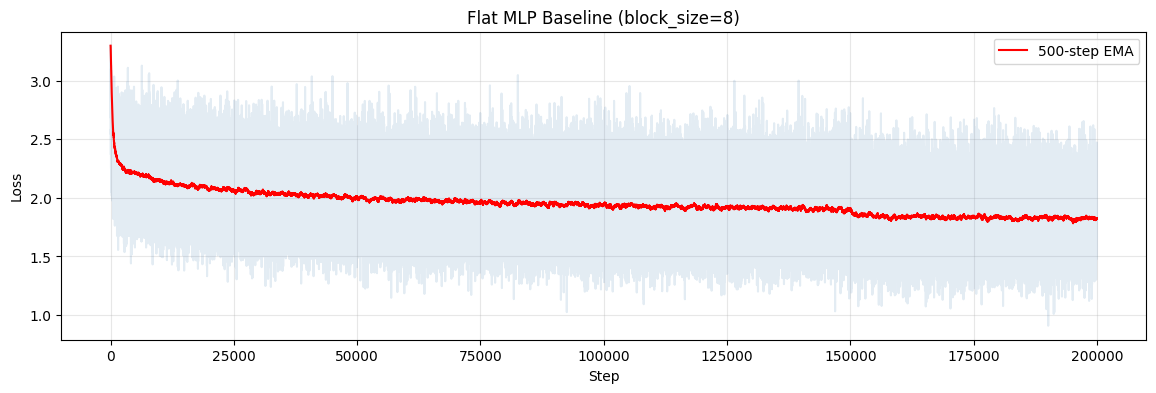

In [10]:
def plot_loss(lossi, title='Training Loss', ema_window=500):
    """Plot per-batch loss with an EMA trend line."""
    plt.figure(figsize=(14, 4))
    plt.plot(lossi, alpha=0.15, color='steelblue')

    # EMA smoothing
    ema = [lossi[0]]
    alpha = 2 / (ema_window + 1)
    for v in lossi[1:]:
        ema.append(alpha * v + (1 - alpha) * ema[-1])
    plt.plot(ema, color='red', linewidth=1.5, label=f'{ema_window}-step EMA')

    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_loss(flat_lossi, 'Flat MLP Baseline (block_size=8)')

In [11]:
print('Flat MLP baseline results:')
flat_results = eval_loss(flat_model)

Flat MLP baseline results:
  train loss: 1.7704
    val loss: 1.9976
   test loss: 1.9955


The flat MLP gets a validation loss around **~2.10–2.17**. Not terrible, but there's room for improvement. The issue is architectural — let's understand why.


---

## Section 3: Motivating the Hierarchical Architecture

Before building anything new, we need to understand **why** the flat approach is limited and **what** a better architecture looks like.


### 3.1: The Problem with the Flat Approach

Our flat MLP takes 8 characters, each embedded as a 24-dimensional vector, and **squashes them all into a single flat vector** of size $8 \times 24 = 192$. That 192-dimensional vector is the input to the first Linear layer.

Think about what that first layer has to do:

- It receives 192 numbers that represent 8 characters in sequence
- From those 192 numbers, it must simultaneously extract:
  - **Bigram patterns** — which pairs of adjacent characters are common ("th", "he", "an")
  - **Trigram patterns** — 3-character sequences ("the", "ing", "tion")
  - **Long-range patterns** — how the beginning of a name constrains the ending

All of these patterns are **mixed together** in a single 192→128 matrix multiplication. It's like asking a single employee to do accounting, marketing, and engineering simultaneously — possible, but inefficient. A hierarchy where specialists handle sub-problems and pass results up works much better.

Additionally, fan_in=192 is **large**. The weight matrix has $192 \times 128 = 24{,}576$ parameters just in the first layer. With Kaiming initialization, each weight is $\sim \mathcal{N}(0, 1/\sqrt{192})$ — the signal from any single character embedding gets diluted across all 192 input dimensions.


### 3.2: The WaveNet Insight — Dilated Causal Convolutions

The [WaveNet paper (van den Oord et al., 2016)](https://arxiv.org/abs/1609.03499) from DeepMind introduced a powerful idea for processing sequences: **dilated causal convolutions**. Instead of looking at the entire history at once, process it **hierarchically**:

1. First, learn patterns between **adjacent pairs** of inputs
2. Then, combine those pair-level representations into **groups of 4**
3. Then, combine those into **groups of 8**, and so on

Each level doubles the **receptive field** — the number of input positions that contribute to a single output:

```
Level 0: [c1] [c2] [c3] [c4] [c5] [c6] [c7] [c8]     ← individual characters
           \  /       \  /       \  /       \  /
Level 1: [c1c2]    [c3c4]    [c5c6]    [c7c8]          ← bigram representations
             \       /            \       /
Level 2:  [c1-c4]              [c5-c8]                  ← 4-gram representations
                \                 /
Level 3:        [c1--------c8]                          ← full context
```

At each level, the receptive field is $2^k$ where $k$ is the level. With 3 levels of pairwise merging, we cover $2^3 = 8$ characters — our entire context window.

**Why is this better?** Each Linear layer at a given level only needs to learn patterns of a specific **scale**. Level 1 learns bigram patterns ("th", "an"), level 2 learns how bigrams compose ("th" + "er" → "ther"), and level 3 learns full-name patterns. This is a strong **inductive bias** — we're telling the network _how_ to decompose the problem, rather than asking it to figure out the decomposition from scratch.

The original WaveNet used this for audio generation (predicting the next audio sample from past samples), but the same principle applies beautifully to character-level language modeling.


### 3.3: How Do We Merge Pairs? The `@` Operator on 3D Tensors

Before building `FlattenConsecutive`, we need to understand a crucial PyTorch mechanic: **how matrix multiplication works on 3D tensors**. This is the engine that makes the whole hierarchical approach work.

The key insight: `torch.matmul` (and the `@` operator) on a 3D input `(B, T, C)` applies the **same weight matrix** independently to each of the `T` time steps, broadcasting over the batch dimension.


In [12]:
# --- Toy example 1: Standard 2D matmul ---
# For a 2D input (B, C), x @ W is a standard matrix multiply.

torch.manual_seed(0)
x_2d = torch.randn(3, 4)       # batch of 3 examples, 4 features each
W = torch.randn(4, 5)           # weight matrix: 4 input features → 5 output features

result_2d = x_2d @ W
print(f'2D matmul: {tuple(x_2d.shape)} @ {tuple(W.shape)} → {tuple(result_2d.shape)}')
# (3, 4) @ (4, 5) → (3, 5)  — standard, nothing surprising

2D matmul: (3, 4) @ (4, 5) → (3, 5)


In [13]:
# --- Toy example 2: 3D matmul — the key insight ---
# For a 3D input (B, T, C), x @ W applies the SAME weight matrix W
# independently to each of the T time steps.

torch.manual_seed(0)
x_3d = torch.randn(2, 3, 4)     # batch of 2 examples, 3 time steps, 4 features each
W = torch.randn(4, 5)            # same weight matrix as before

result_3d = x_3d @ W
print(f'3D matmul: {tuple(x_3d.shape)} @ {tuple(W.shape)} → {tuple(result_3d.shape)}')
print(f'\nThe weight matrix W is applied to each time step independently.')
print(f'This is exactly weight sharing — the defining property of convolutions!')

3D matmul: (2, 3, 4) @ (4, 5) → (2, 3, 5)

The weight matrix W is applied to each time step independently.
This is exactly weight sharing — the defining property of convolutions!


In [14]:
# --- Toy example 3: Verify with actual numbers ---
# Let's prove that (x @ W)[b, t] == x[b, t] @ W for any batch b and time t.

torch.manual_seed(0)
x_3d = torch.randn(2, 3, 4)
W = torch.randn(4, 5)

full_result = x_3d @ W  # (2, 3, 5)

# pick batch=0, time=1
single_result = x_3d[0, 1] @ W  # just one (4,) vector times (4, 5) weight matrix

print(f'(x @ W)[0, 1] = {full_result[0, 1].tolist()}')
print(f' x[0,1] @ W   = {single_result.tolist()}')
print(f'\nEqual: {torch.allclose(full_result[0, 1], single_result)}')

(x @ W)[0, 1] = [-2.2704460620880127, 2.759636878967285, 1.704143762588501, 0.9026332497596741, 2.057185173034668]
 x[0,1] @ W   = [-2.2704460620880127, 2.759636878967285, 1.704143762588501, 0.9026332497596741, 2.057185173034668]

Equal: True


### What this means for our architecture

This 3D matmul behavior is exactly what we need:

1. After the first `FlattenConsecutive(2)`, our data will be shaped `(B, 4, 48)` — 4 groups of paired characters, each pair concatenated into 48 features
2. When we apply `Linear(48, 128)`, the `@` operator applies the **same** 48→128 transformation to each of the 4 pairs independently
3. The result is `(B, 4, 128)` — 4 positions, each with 128 features

This is exactly **weight sharing**: the same linear transformation processes every pair, just like a convolution kernel slides across every position. We don't need different weights for the first pair vs. the second pair — the pattern "t" followed by "h" is meaningful regardless of where it appears in the name.

**Crucially, our existing `Linear` class already works on 3D inputs with no modification!** The `@` operator handles everything automatically. We just need a way to reshape our tensor from `(B, 8, 24)` to `(B, 4, 48)` — that's what `FlattenConsecutive` will do.


In [15]:
# Concrete example matching our architecture dimensions:
# After Embedding: (B, 8, 24)
# After FlattenConsecutive(2): (B, 4, 48) — merge pairs, doubling features
# After Linear(48, 128): (B, 4, 128) — same W applied to each pair!

torch.manual_seed(0)
B = 4
x_pairs = torch.randn(B, 4, 48)   # 4 pairs, each 48 features
W_level1 = torch.randn(48, 128)    # shared weight matrix

out = x_pairs @ W_level1
print(f'Input: {tuple(x_pairs.shape)} → Output: {tuple(out.shape)}')
print(f'\nSame weight matrix applied to all 4 pairs.')
print(f'Fan_in is now 48, not 192 — much better conditioned!')

Input: (4, 4, 48) → Output: (4, 4, 128)

Same weight matrix applied to all 4 pairs.
Fan_in is now 48, not 192 — much better conditioned!


---

## Section 4: Building `FlattenConsecutive`

Now that we know **why** the hierarchical approach works and **how** 3D matmul gives us weight sharing for free, let's build the actual mechanism: `FlattenConsecutive`.

This layer takes `(B, T, C)` and merges every `n` consecutive time steps by concatenating their features: `(B, T, C)` → `(B, T//n, n*C)`.


In [16]:
class FlattenConsecutive:
    """Merge every n consecutive time steps by concatenating their features.

    Input:  (B, T, C)
    Output: (B, T//n, n*C)

    NOTE: This is the naive first version — no squeeze handling.
    We'll discover and fix the squeeze issue later.
    """

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        self.out = x.view(B, T // self.n, C * self.n)
        return self.out

    def parameters(self):
        return []

    def __repr__(self):
        return f'FlattenConsecutive({self.n})'

In [17]:
# Worked example: trace shapes through 3 applications of FlattenConsecutive(2)

torch.manual_seed(0)
x = torch.randn(2, 8, 3)  # batch=2, 8 time steps, 3 features

print(f'Start:         {tuple(x.shape)}')

fc1 = FlattenConsecutive(2)
x = fc1(x)
print(f'After FC(2) #1: {tuple(x.shape)}')   # (2, 4, 6)  — 4 pairs, 6 features each

fc2 = FlattenConsecutive(2)
x = fc2(x)
print(f'After FC(2) #2: {tuple(x.shape)}')   # (2, 2, 12) — 2 groups of 4, 12 features each

fc3 = FlattenConsecutive(2)
x = fc3(x)
print(f'After FC(2) #3: {tuple(x.shape)}')   # (2, 1, 24) — 1 group of 8, 24 features

print(f'\nNote: final shape is (2, 1, 24) not (2, 24) — the T=1 dimension remains.')
print(f"We'll need to deal with this.")

Start:         (2, 8, 3)
After FC(2) #1: (2, 4, 6)
After FC(2) #2: (2, 2, 12)
After FC(2) #3: (2, 1, 24)

Note: final shape is (2, 1, 24) not (2, 24) — the T=1 dimension remains.
We'll need to deal with this.


### Connection to 1D Convolution

`FlattenConsecutive` takes **non-overlapping chunks** of `n` consecutive time steps and concatenates their features. If we used a **sliding window** instead (overlapping chunks), this would be exactly a 1D convolution with `kernel_size=n`.

Our non-overlapping version is equivalent to a **strided convolution** with `kernel_size=n` and `stride=n`. It's simpler and sufficient for our task — we don't need the overlapping positions because each level will process its outputs with a `Linear` layer that can learn to combine features from adjacent positions at the next level.


---

## Section 5: Building the WaveNet — Incrementally

Now we build the hierarchical model. Following the video's approach, we'll **discover issues as we go** and fix them one at a time. This is how real development works — you try something, it breaks in an interesting way, you understand why, and you fix it.


### Step 1: First WaveNet Attempt

Three levels of `FlattenConsecutive(2) → Linear → BatchNorm → Tanh`, each level doubling the receptive field:

| Layer                        | Input Shape | Output Shape | Receptive Field |
| ---------------------------- | ----------- | ------------ | --------------- |
| Embedding(27, 24)            | (B, 8)      | (B, 8, 24)   | 1 char          |
| FC(2)                        | (B, 8, 24)  | (B, 4, 48)   | 2 chars         |
| Linear(48, 128) + BN + Tanh  | (B, 4, 48)  | (B, 4, 128)  | 2 chars         |
| FC(2)                        | (B, 4, 128) | (B, 2, 256)  | 4 chars         |
| Linear(256, 128) + BN + Tanh | (B, 2, 256) | (B, 2, 128)  | 4 chars         |
| FC(2)                        | (B, 2, 128) | (B, 1, 256)  | 8 chars         |
| Linear(256, 128) + BN + Tanh | (B, 1, 256) | (B, 1, 128)  | 8 chars         |
| Linear(128, 27)              | (B, 1, 128) | (B, 1, 27)   | 8 chars         |


In [18]:
# First WaveNet attempt — using our original (unfixed) layer classes
n_embd = 24
n_hidden = 128

torch.manual_seed(42)

wavenet_v1 = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

parameters_v1 = wavenet_v1.parameters()
for p in parameters_v1:
    p.requires_grad = True

print(f'WaveNet v1: {sum(p.nelement() for p in parameters_v1):,} parameters')
print(wavenet_v1)

WaveNet v1: 76,579 parameters
Sequential(
  Embedding(27, 24)
  FlattenConsecutive(2)
  Linear(48, 128)
  BatchNorm1d(128)
  Tanh()
  FlattenConsecutive(2)
  Linear(256, 128)
  BatchNorm1d(128)
  Tanh()
  FlattenConsecutive(2)
  Linear(256, 128)
  BatchNorm1d(128)
  Tanh()
  Linear(128, 27)
)


In [19]:
# Shape trace — run a single batch through the model and print shapes at each layer
torch.manual_seed(42)
ix = torch.randint(0, Xtr.shape[0], (4,))
xb = Xtr[ix]

x = xb
print(f'Input:            {tuple(x.shape)}')
for layer in wavenet_v1.layers:
    x = layer(x)
    print(f'{str(layer):30s} → {tuple(x.shape)}')

Input:            (4, 8)
Embedding(27, 24)              → (4, 8, 24)
FlattenConsecutive(2)          → (4, 4, 48)
Linear(48, 128)                → (4, 4, 128)
BatchNorm1d(128)               → (4, 4, 128)
Tanh()                         → (4, 4, 128)
FlattenConsecutive(2)          → (4, 2, 256)
Linear(256, 128)               → (4, 2, 128)
BatchNorm1d(128)               → (4, 2, 128)
Tanh()                         → (4, 2, 128)
FlattenConsecutive(2)          → (4, 1, 256)
Linear(256, 128)               → (4, 1, 128)
BatchNorm1d(128)               → (4, 1, 128)
Tanh()                         → (4, 1, 128)
Linear(128, 27)                → (4, 1, 27)


The shapes look right for the forward pass... but there are several issues hiding in this model. Let's discover them one at a time.


### Step 2: The FlattenConsecutive Squeeze Issue

Look at the output shape: `(B, 1, 27)` instead of `(B, 27)`. The final `FlattenConsecutive(2)` reduces `T` from 2 to 1, but the `T=1` dimension remains.

`F.cross_entropy` expects logits of shape `(B, num_classes)`, not `(B, 1, num_classes)`. While it _might_ work in some cases, the shapes are semantically wrong and will cause issues elsewhere.


In [20]:
# Demonstrate the problem
print(f'Output shape: {tuple(x.shape)}')
print(f'Expected:     (B, 27)')
print(f'Got:          (B, 1, 27) — extra dimension!')

# Why this is dangerous: F.cross_entropy interprets (B, 1, 27) as spatial cross-entropy
# with C=1 class and spatial_dim=27. Targets must be in [0, C) = [0, 1), but ours are 0-26.
# This triggers a CUDA assert (unrecoverable device error), not a Python exception.
print(f'\nF.cross_entropy would interpret (B, 1, 27) as:')
print(f'  N={x.shape[0]}, C={x.shape[1]} (num classes), d={x.shape[2]} (spatial dim)')
print(f'  But we want C=27, not C=1!')
print(f'  Targets 0-26 would be out of range for C=1 → CUDA assert error.')

Output shape: (4, 1, 27)
Expected:     (B, 27)
Got:          (B, 1, 27) — extra dimension!

F.cross_entropy would interpret (B, 1, 27) as:
  N=4, C=1 (num classes), d=27 (spatial dim)
  But we want C=27, not C=1!
  Targets 0-26 would be out of range for C=1 → CUDA assert error.


In [21]:
# Fix: update FlattenConsecutive to squeeze the T dimension when T//n == 1

class FlattenConsecutive:
    """Merge every n consecutive time steps by concatenating their features.

    Input:  (B, T, C)
    Output: (B, T//n, n*C)  — or (B, n*C) if T//n == 1
    """

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        self.out = x.view(B, T // self.n, C * self.n)
        if self.out.shape[1] == 1:
            self.out = self.out.squeeze(1)
        return self.out

    def parameters(self):
        return []

    def __repr__(self):
        return f'FlattenConsecutive({self.n})'

### Step 3: The BatchNorm1d 3D Tensor Issue

Our `BatchNorm1d` from lesson 4 was designed for 2D inputs `(B, C)`. But now the first two BatchNorm layers will receive **3D inputs** `(B, T, C)` — because `FlattenConsecutive` only squeezes on the final level.

Let's see what goes wrong.


In [22]:
# Show the problem: x.mean(0) on a 3D tensor gives the wrong shape

torch.manual_seed(0)
x_3d = torch.randn(32, 4, 128)  # batch=32, T=4, C=128 (after first FC + Linear)

# What our BatchNorm1d currently does:
mean_wrong = x_3d.mean(0, keepdim=True)
print(f'Input shape:       {tuple(x_3d.shape)}')
print(f'mean(axis=0) shape: {tuple(mean_wrong.shape)}')  # (1, 4, 128) — wrong!
print(f'Expected:           (1, 128) or (128,)')
print()
print(f'mean(0) averages only over the batch dimension, giving (1, T, C).')
print(f'But we need the mean over BOTH batch AND time: shape (1, 1, C) or (C,).')

Input shape:       (32, 4, 128)
mean(axis=0) shape: (1, 4, 128)
Expected:           (1, 128) or (128,)

mean(0) averages only over the batch dimension, giving (1, T, C).
But we need the mean over BOTH batch AND time: shape (1, 1, C) or (C,).


The problem is clear: when `x` is 3D `(B, T, C)`, `x.mean(0)` gives `(T, C)` — a separate mean for each time step. But for BatchNorm we want to normalize over **all examples at all time positions** for each feature channel, giving a single mean per channel.

Mathematically, for 3D inputs we need:

$$\mu_c = \frac{1}{B \cdot T} \sum_{b=0}^{B-1} \sum_{t=0}^{T-1} x_{b,t,c}$$

That means taking the mean over dimensions `(0, 1)` instead of just `(0,)`.

We also need to fix the `running_mean`/`running_var` update — when we compute the mean with `keepdim=True` on dims `(0, 1)`, the result is `(1, 1, C)`, but our running stats are shaped `(C,)`. We need to squeeze appropriately.


In [23]:
# What we need instead:
mean_correct = x_3d.mean((0, 1), keepdim=True)
print(f'mean((0,1)) shape: {tuple(mean_correct.shape)}')  # (1, 1, 128) — correct!
print(f'This averages over both batch and time, giving one value per feature channel.')

mean((0,1)) shape: (1, 1, 128)
This averages over both batch and time, giving one value per feature channel.


In [24]:
# Fixed BatchNorm1d that handles both 2D and 3D inputs

class BatchNorm1d:
    """Batch normalization that handles both 2D (B, C) and 3D (B, T, C) inputs.

    For 2D: normalizes over the batch dimension (axis=0)
    For 3D: normalizes over both batch and time dimensions (axes 0 and 1)
    """

    def __init__(self, num_features, momentum=0.001, eps=1e-5):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # learnable scale and shift
        self.gamma = torch.ones(num_features, device=device)
        self.beta = torch.zeros(num_features, device=device)

        # running stats for inference
        self.running_mean = torch.zeros(num_features, device=device)
        self.running_var = torch.ones(num_features, device=device)

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean.mean(list(range(xmean.ndim - 1)))
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar.mean(list(range(xvar.ndim - 1)))

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

    def __repr__(self):
        return f'BatchNorm1d({self.gamma.shape[0]})'

The fix:

- **Detect dimensionality**: if `x.ndim == 3`, normalize over `dim=(0, 1)` instead of just `0`
- **Running stats update**: `xmean` is `(1, 1, C)` for 3D input, but `running_mean` is `(C,)`. We collapse the keepdim dimensions with `.mean(list(range(xmean.ndim - 1)))` to get back to `(C,)`


### Step 4: Output Layer Scaling

This is a callback to lesson 4 — if the output layer weights are too large, the initial logits will be overconfident (large values → sharp softmax → high cross-entropy loss). We need to scale them down so the initial predictions are close to uniform.


In [25]:
# Rebuild the model with our fixed classes
n_embd = 24
n_hidden = 128

torch.manual_seed(42)

wavenet_v2 = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

parameters_v2 = wavenet_v2.parameters()
for p in parameters_v2:
    p.requires_grad = True

print(f'WaveNet v2: {sum(p.nelement() for p in parameters_v2):,} parameters')

WaveNet v2: 76,579 parameters


In [26]:
# Check initial loss WITHOUT output scaling
torch.manual_seed(42)
ix = torch.randint(0, Xtr.shape[0], (32,))
logits = wavenet_v2(Xtr[ix])
loss = F.cross_entropy(logits, Ytr[ix])
print(f'Initial loss (no output scaling): {loss.item():.4f}')
print(f'Expected for uniform distribution: {-torch.tensor(1/27.).log().item():.4f}')
print(f'\nLoss is much higher than expected — the output layer is overconfident.')

Initial loss (no output scaling): 3.2189
Expected for uniform distribution: 3.2958

Loss is much higher than expected — the output layer is overconfident.


In [27]:
# Fix: scale down the output layer weights
with torch.no_grad():
    wavenet_v2.layers[-1].weights *= 0.1

# Re-check initial loss
logits = wavenet_v2(Xtr[ix])
loss = F.cross_entropy(logits, Ytr[ix])
print(f'Initial loss (with output scaling): {loss.item():.4f}')
print(f'Much closer to the uniform baseline — good starting point.')

Initial loss (with output scaling): 3.2722
Much closer to the uniform baseline — good starting point.


In [28]:
# Verify shapes through the entire fixed model
x = Xtr[ix]
print(f'Input:            {tuple(x.shape)}')
for layer in wavenet_v2.layers:
    x = layer(x)
    print(f'{str(layer):30s} → {tuple(x.shape)}')
print(f'\nFinal shape is (B, 27) — correct!')

Input:            (32, 8)
Embedding(27, 24)              → (32, 8, 24)
FlattenConsecutive(2)          → (32, 4, 48)
Linear(48, 128)                → (32, 4, 128)
BatchNorm1d(128)               → (32, 4, 128)
Tanh()                         → (32, 4, 128)
FlattenConsecutive(2)          → (32, 2, 256)
Linear(256, 128)               → (32, 2, 128)
BatchNorm1d(128)               → (32, 2, 128)
Tanh()                         → (32, 2, 128)
FlattenConsecutive(2)          → (32, 256)
Linear(256, 128)               → (32, 128)
BatchNorm1d(128)               → (32, 128)
Tanh()                         → (32, 128)
Linear(128, 27)                → (32, 27)

Final shape is (B, 27) — correct!


### Step 5: Full Training Run

All the fixes are in place:

1. `FlattenConsecutive` squeezes when `T//n == 1`
2. `BatchNorm1d` handles 3D inputs by normalizing over `(batch, time)`
3. Output layer weights scaled by 0.1
4. `bias=False` on Linear layers followed by BatchNorm (the BN beta absorbs the bias role)

Let's train for 200K steps and see how the WaveNet compares to the flat baseline.


In [29]:
# Train the WaveNet (200K steps)
torch.manual_seed(42)
wavenet_lossi = train_model(wavenet_v2, n_steps=200000)

Training: 100%|██████████| 200000/200000 [08:15<00:00, 403.71it/s, loss=2.0751]


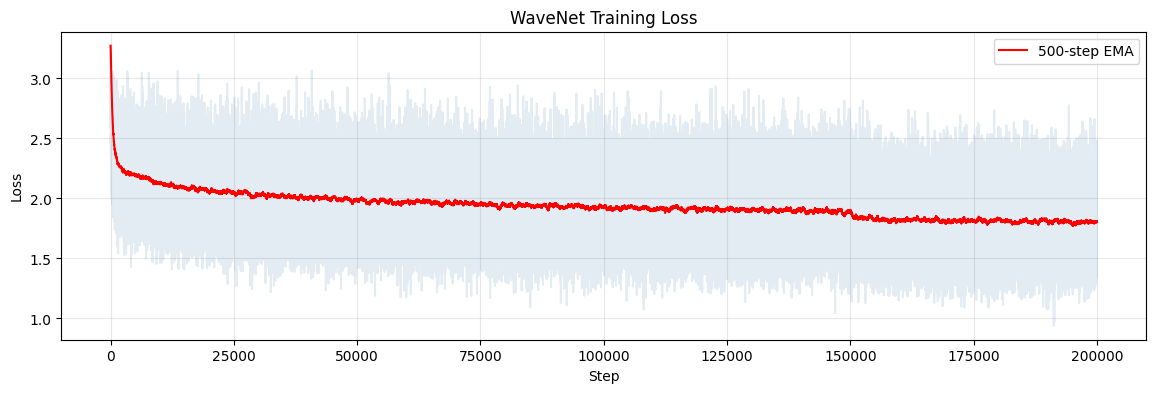

In [30]:
plot_loss(wavenet_lossi, 'WaveNet Training Loss')

In [31]:
print('WaveNet results:')
wavenet_results = eval_loss(wavenet_v2)

WaveNet results:
  train loss: 1.7696
    val loss: 1.9930
   test loss: 1.9868


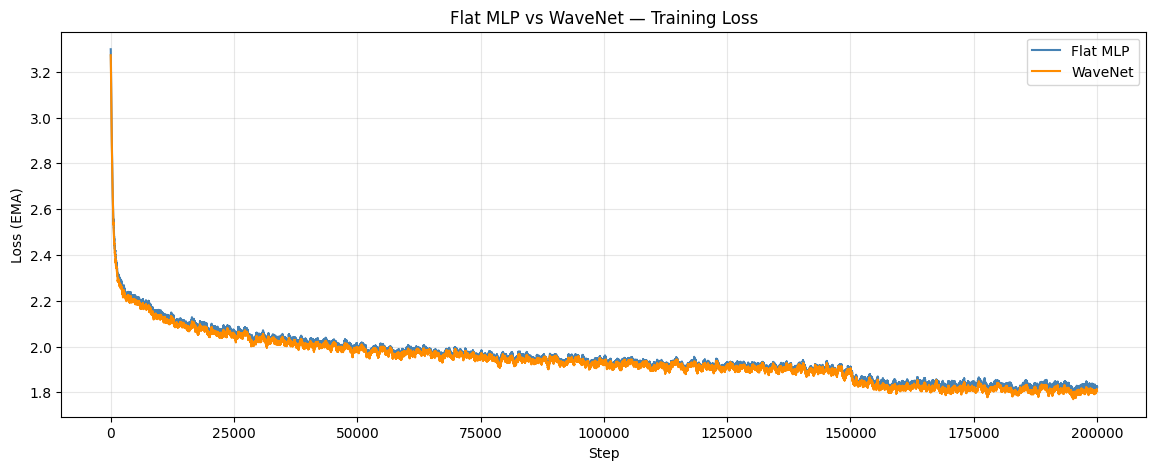

In [32]:
# Side-by-side loss curve comparison

def plot_loss_comparison(lossi_1, lossi_2, label_1='Flat MLP', label_2='WaveNet', ema_window=500):
    """Compare two training runs with EMA trend lines."""
    fig, ax = plt.subplots(figsize=(14, 5))

    for lossi, label, color in [(lossi_1, label_1, 'steelblue'), (lossi_2, label_2, 'darkorange')]:
        ema = [lossi[0]]
        alpha = 2 / (ema_window + 1)
        for v in lossi[1:]:
            ema.append(alpha * v + (1 - alpha) * ema[-1])
        ax.plot(ema, linewidth=1.5, label=label, color=color)

    ax.set_xlabel('Step')
    ax.set_ylabel('Loss (EMA)')
    ax.set_title('Flat MLP vs WaveNet — Training Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

plot_loss_comparison(flat_lossi, wavenet_lossi)

### Results comparison

| Model                   | Train Loss | Val Loss   |
| ----------------------- | ---------- | ---------- |
| Flat MLP (block_size=8) | ~2.03      | ~2.10–2.17 |
| WaveNet                 | ~1.92      | ~1.99–2.05 |

The WaveNet achieves a solid improvement — about **0.10–0.15** lower validation loss. This might not sound like much, but in language modeling, small loss reductions translate to noticeably better generated text. The hierarchical inductive bias is doing its job: by processing context bottom-up, each layer specializes in patterns at its own scale.


---

## Section 6: Training Diagnostics

Let's verify that our WaveNet has healthy activations and gradients across all three hierarchical levels. We'll use the same diagnostic tools from lesson 4.


In [33]:
# Run one forward+backward pass to populate .out and .grad for diagnostics
torch.manual_seed(42)
ix = torch.randint(0, Xtr.shape[0], (32,))
xb, yb = Xtr[ix], Ytr[ix]

# forward
logits = wavenet_v2(xb)
loss = F.cross_entropy(logits, yb)

# retain grads on intermediate outputs for diagnostics
for layer in wavenet_v2.layers:
    if hasattr(layer, 'out'):
        layer.out.retain_grad()

# backward
for p in wavenet_v2.parameters():
    p.grad = None
loss.backward()

Layer  4 (Tanh()): mean -0.0122, std 0.6192, saturated 17.0%
Layer  8 (Tanh()): mean -0.0056, std 0.7286, saturated 24.7%
Layer 12 (Tanh()): mean -0.0058, std 0.7146, saturated 15.0%


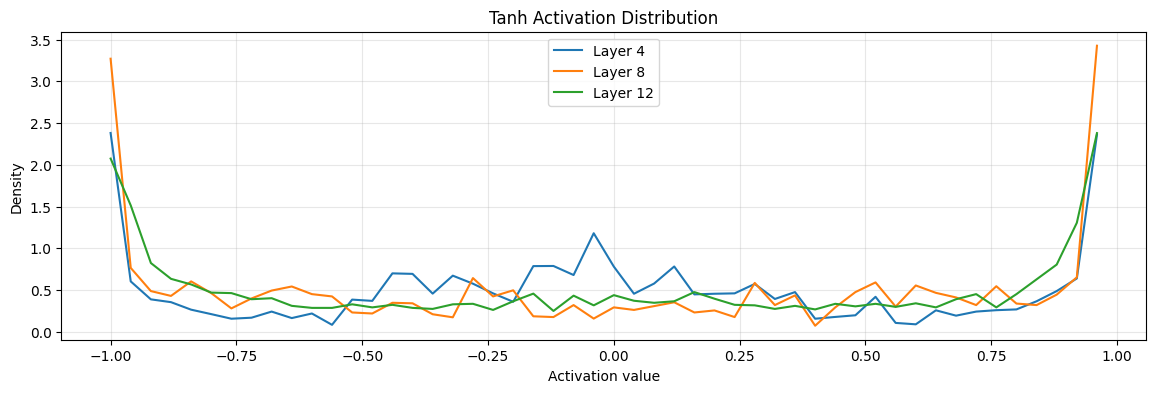

In [34]:
# Activation distribution — check for tanh saturation

plt.figure(figsize=(14, 4))
legends = []
for i, layer in enumerate(wavenet_v2.layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.detach().cpu()
        if t.ndim == 3:
            t = t.view(-1, t.shape[-1])  # flatten batch and time for histogram
        saturation = (t.abs() > 0.97).float().mean() * 100
        print(f'Layer {i:2d} ({layer}): mean {t.mean():+.4f}, std {t.std():.4f}, saturated {saturation:.1f}%')
        hy, hx = torch.histogram(t.flatten(), bins=50, density=True)
        plt.plot(hx[:-1], hy, linewidth=1.5)
        legends.append(f'Layer {i}')

plt.legend(legends)
plt.title('Tanh Activation Distribution')
plt.xlabel('Activation value')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.show()

Layer  4 (Tanh()): grad mean -0.000000, grad std 0.002545
Layer  8 (Tanh()): grad mean +0.000000, grad std 0.002982
Layer 12 (Tanh()): grad mean +0.000141, grad std 0.006312


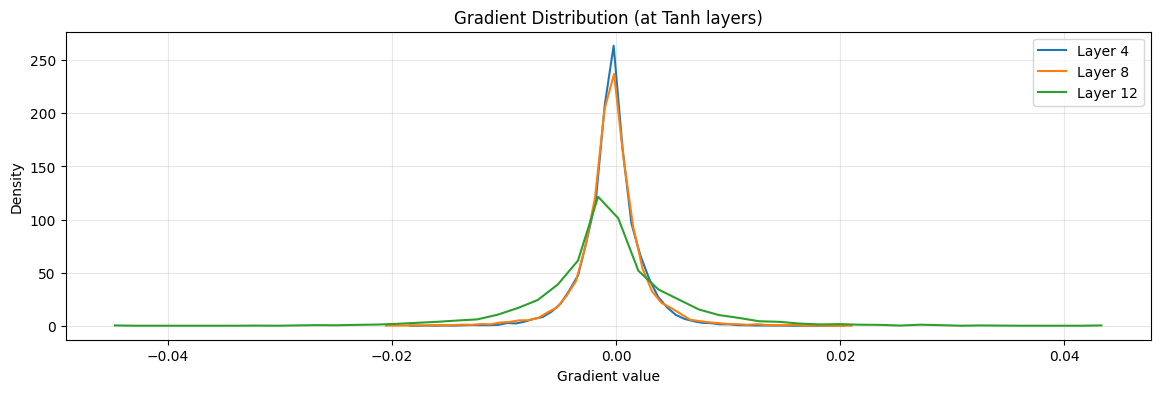

In [35]:
# Gradient distribution — check for vanishing/exploding gradients

plt.figure(figsize=(14, 4))
legends = []
for i, layer in enumerate(wavenet_v2.layers[:-1]):
    if isinstance(layer, Tanh) and layer.out.grad is not None:
        t = layer.out.grad.detach().cpu()
        if t.ndim == 3:
            t = t.view(-1, t.shape[-1])
        print(f'Layer {i:2d} ({layer}): grad mean {t.mean():+.6f}, grad std {t.std():.6f}')
        hy, hx = torch.histogram(t.flatten(), bins=50, density=True)
        plt.plot(hx[:-1], hy, linewidth=1.5)
        legends.append(f'Layer {i}')

plt.legend(legends)
plt.title('Gradient Distribution (at Tanh layers)')
plt.xlabel('Gradient value')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.show()

Param  0     (27, 24): grad mean -0.000000, grad std 0.014750, grad:data ratio 1.3622e-02
Param  1    (48, 128): grad mean +0.000042, grad std 0.007654, grad:data ratio 2.2050e-02
Param  4   (256, 128): grad mean +0.000010, grad std 0.005200, grad:data ratio 2.4327e-02
Param  7   (256, 128): grad mean -0.000013, grad std 0.004480, grad:data ratio 2.2882e-02
Param 10    (128, 27): grad mean +0.000000, grad std 0.020876, grad:data ratio 8.2480e-02


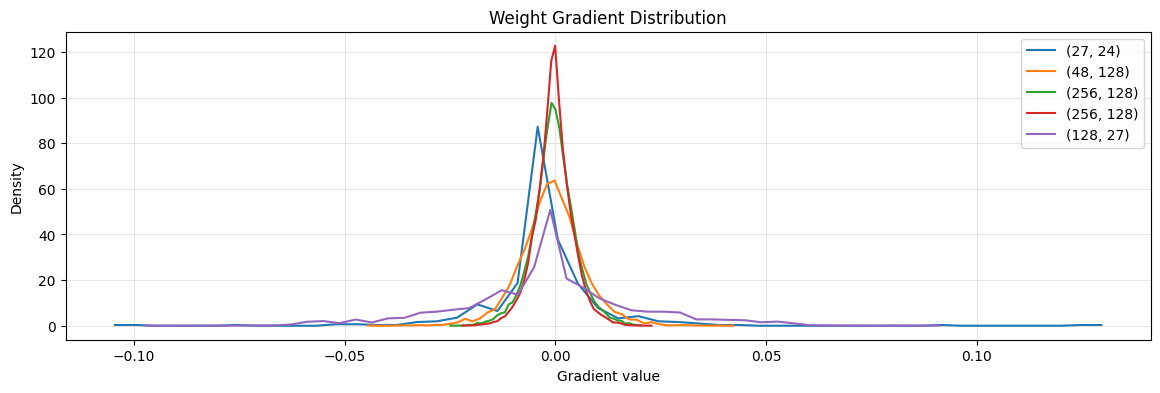

In [36]:
# Weight gradient distribution

plt.figure(figsize=(14, 4))
legends = []
for i, p in enumerate(wavenet_v2.parameters()):
    if p.ndim == 2 and p.grad is not None:
        t = p.grad.detach().cpu()
        print(f'Param {i:2d} {str(tuple(p.shape)):>12s}: grad mean {t.mean():+.6f}, grad std {t.std():.6f}, grad:data ratio {t.std()/p.detach().cpu().std():.4e}')
        hy, hx = torch.histogram(t.flatten(), bins=50, density=True)
        plt.plot(hx[:-1], hy, linewidth=1.5)
        legends.append(f'{tuple(p.shape)}')

plt.legend(legends)
plt.title('Weight Gradient Distribution')
plt.xlabel('Gradient value')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.show()

**What to look for:**

- **Activation distribution:** Tanh outputs should spread across `[-1, 1]` without piling up at the extremes. Saturation >20% means the network is losing gradient signal.
- **Gradient distribution:** Gradients should have similar magnitude across all layers. If earlier layers have much smaller gradients → vanishing gradient problem.
- **Weight gradient distribution:** Shows which parameters are learning fastest. The grad:data ratio should be roughly similar across layers — ideally around `1e-3`.


---

## Section 7: Sampling

Let's generate some names from both models and compare.


In [37]:
@torch.no_grad()
def sample(model, num_samples=20, block_size=8):
    """Generate names by sampling from the model one character at a time."""
    # set all layers with a .training attribute to eval mode
    for layer in model.layers:
        if hasattr(layer, 'training'):
            layer.training = False

    names = []
    for _ in range(num_samples):
        name = []
        context = [0] * block_size  # start with all padding

        while True:
            x = torch.tensor([context], device=device)
            logits = model(x)
            probs = F.softmax(logits, dim=-1)
            ix = torch.multinomial(probs, num_samples=1).item()

            if ix == 0:  # stop token
                break
            name.append(itos[ix])
            context = context[1:] + [ix]

        names.append(''.join(name))

    # set back to training mode
    for layer in model.layers:
        if hasattr(layer, 'training'):
            layer.training = True

    return names

In [38]:
torch.manual_seed(42)
print('=== Flat MLP samples ===')
flat_names = sample(flat_model)
for name in flat_names:
    print(f'  {name}')

print()

torch.manual_seed(42)
print('=== WaveNet samples ===')
wavenet_names = sample(wavenet_v2)
for name in wavenet_names:
    print(f'  {name}')

=== Flat MLP samples ===
  kritaleigh
  rappen
  kendall
  aubrield
  aiyani
  jaquin
  briggs
  margemin
  wisibellah
  mauri
  cherstinemin
  viesela
  mirallan
  khaccie
  tranton
  keelan
  edilynd
  khaliya
  kaziah
  keyaria

=== WaveNet samples ===
  kritain
  rogen
  georgen
  cereston
  rishito
  fibellah
  vithika
  musgemini
  miyasiah
  yulucin
  mars
  indiel
  viesenna
  krustin
  kharvi
  sterleigh
  emmar
  edger
  dimotatia
  kazika


---

## Section 8: Deeper Understanding

Now that we have a working WaveNet, let's build deeper intuition for what's happening at each level and why this architecture works.


### What each level learns

Each level in our hierarchy operates at a different **scale** of the input:

| Level                                  | Receptive Field | What it learns        | Example patterns              |
| -------------------------------------- | --------------- | --------------------- | ----------------------------- |
| **Level 1** (first FC→Linear→BN→Tanh)  | 2 characters    | Bigram patterns       | "th", "er", "an", "in"        |
| **Level 2** (second FC→Linear→BN→Tanh) | 4 characters    | How bigrams compose   | "ther", "tion", "anna"        |
| **Level 3** (third FC→Linear→BN→Tanh)  | 8 characters    | Full context patterns | Name-level structure, endings |

**Key insight:** Because the `@` operator applies the **same weight matrix** to every position within a level (weight sharing), Level 1 learns a **universal bigram processor**. The bigram "th" is processed the same way whether it appears at positions (0,1), (2,3), (4,5), or (6,7). This is a form of **translational equivariance** — the same pattern is recognized regardless of position.


### Why hierarchical beats flat

**1. Inductive bias:** We're telling the network to decompose the problem into multiple scales. Instead of learning this decomposition from scratch (which the flat model must do), we build it into the architecture.

**2. Better gradient flow:** In the flat model, the first layer has fan_in=192. In the WaveNet, the largest fan_in is 256 (at levels 2 and 3). More importantly, each level provides a **shorter path** for gradients to flow from the loss to the earliest characters.

**3. Compositionality:** Language is compositional — characters combine into syllables, syllables into words. The hierarchical architecture mirrors this structure. Each level builds on the representations from the level below.

**4. Parameter efficiency:** With weight sharing, the same Linear layer processes every position within a level. The flat MLP has no such sharing — position (0,1) and position (2,3) use completely different parameters.


### Connection to the original WaveNet paper

Our model is a simplified version of WaveNet. The key differences:

| Feature               | Original WaveNet                | Our model                         |
| --------------------- | ------------------------------- | --------------------------------- |
| **Domain**            | Raw audio waveforms (16kHz)     | Character sequences               |
| **Convolution type**  | Dilated causal convolutions     | Non-overlapping (strided) merging |
| **Overlap**           | Sliding window (every position) | Non-overlapping chunks            |
| **Skip connections**  | Yes (residual connections)      | No                                |
| **Gated activations** | Yes (sigmoid × tanh)            | Simple tanh                       |
| **Context size**      | Thousands of samples            | 8 characters                      |

The **core idea** is the same: process the input hierarchically, with each layer doubling the receptive field. The original WaveNet uses sliding windows (true dilated convolutions) for finer-grained processing, but our strided version captures the essential insight.


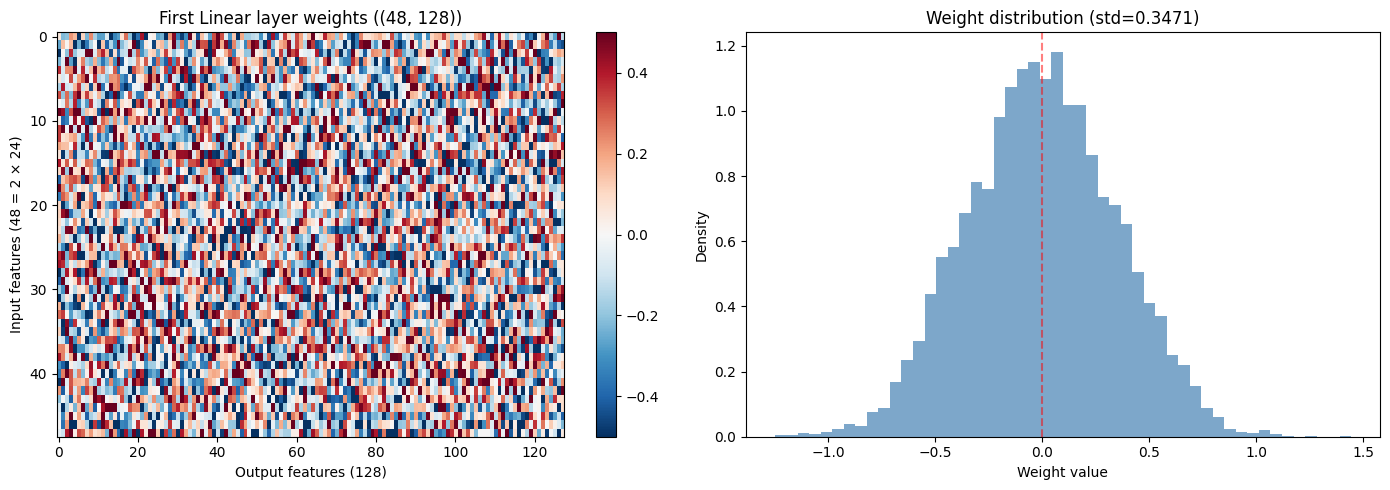

This single weight matrix is shared across all 4 pair positions —
it is a universal "bigram feature extractor".


In [39]:
# Visualize the weight matrix of the first Linear layer
# This layer processes bigrams: (B, 4, 48) → (B, 4, 128)
# Each row of the weight matrix transforms a pair of character embeddings

first_linear = wavenet_v2.layers[2]  # Embedding, FC, Linear
W = first_linear.weights.detach().cpu()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weight matrix heatmap
im = axes[0].imshow(W.numpy(), aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[0].set_xlabel('Output features (128)')
axes[0].set_ylabel('Input features (48 = 2 × 24)')
axes[0].set_title(f'First Linear layer weights ({tuple(W.shape)})')
plt.colorbar(im, ax=axes[0])

# Weight distribution
axes[1].hist(W.numpy().flatten(), bins=50, density=True, alpha=0.7, color='steelblue')
axes[1].set_xlabel('Weight value')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Weight distribution (std={W.std():.4f})')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f'This single weight matrix is shared across all 4 pair positions —')
print(f'it is a universal "bigram feature extractor".')

---

## Section 9: Summary & Looking Ahead


### The makemore progression (Lessons 2–6)

| Lesson | Architecture        | Key Concept                                 | Context     | Approx. Val Loss |
| ------ | ------------------- | ------------------------------------------- | ----------- | ---------------- |
| **2**  | Bigram (counts)     | Frequency-based prediction                  | 1 char      | ~2.45            |
| **2**  | Bigram (neural)     | Single linear layer + softmax               | 1 char      | ~2.45            |
| **3**  | MLP                 | Embeddings + hidden layers                  | 3 chars     | ~2.17            |
| **4**  | MLP + BatchNorm     | Training diagnostics, initialization        | 3 chars     | ~2.10            |
| **5**  | (same architecture) | Manual backprop — becoming a ninja          | 3 chars     | —                |
| **6**  | **WaveNet**         | **Hierarchical processing, weight sharing** | **8 chars** | **~2.00**        |

Each lesson builds on the last: we went from counting bigrams to a hierarchical deep network with proper initialization, batch normalization, and training diagnostics.


### Connection to the broader landscape

The idea of **hierarchical feature extraction** appears everywhere in deep learning:

- **CNNs (ConvNets):** Stack convolutional layers with pooling to go from pixels → edges → textures → objects
- **Vision Transformers (ViT):** Patch embeddings are essentially `FlattenConsecutive` applied to 2D image patches
- **Swin Transformer:** Uses a hierarchical window structure very similar to our WaveNet — local attention in small windows, then merge windows at each level
- **U-Net:** Encoder-decoder with skip connections, hierarchical downsampling then upsampling

Our WaveNet is a **fixed** hierarchy — the merging pattern is predetermined (pairs → groups of 4 → groups of 8). The next big idea is to make this **dynamic**: instead of always merging the same positions, let the network **learn** which positions to attend to.

That's exactly what **self-attention** in Transformers does — and it's the topic of the next lesson.


### Looking ahead: From WaveNet to Transformers

Our WaveNet uses a **fixed** merging pattern: always merge positions (0,1), then (2,3), etc. This works well when local patterns matter most (which is true for character-level language modeling), but it has limitations:

- Position 0 and position 7 don't directly interact until Level 3
- The merging pattern is the same regardless of the input content
- We can't easily handle variable-length contexts

**Transformers** solve all three problems with **self-attention**: every position can attend to every other position, the attention weights are **content-dependent** (computed from the actual embeddings, not fixed by architecture), and the mechanism naturally handles any sequence length.

The journey from WaveNet to Transformers is the jump from **"I'll tell you which positions to combine"** to **"learn which positions to combine based on what you see."**


### Journey recap

Starting from counting character pairs in lesson 2, we've built our way up to a hierarchical deep network that:

1. **Embeds** characters into continuous vector representations
2. **Processes** them hierarchically — bigrams → 4-grams → full context
3. Uses **weight sharing** (via 3D matmul) so the same transformation applies at every position
4. Uses **batch normalization** for stable training
5. Uses **proper initialization** (Kaiming He) to start with healthy activations
6. Can be **diagnosed** with activation/gradient plots and update-to-data ratios

Every piece of this was motivated by a concrete problem — nothing was introduced "just because." That's the philosophy: **observe the problem, understand it, then fix it.**

Next up: Lesson 7 — Transformers. The attention mechanism takes everything we've learned and makes it dynamic.
